# Feature Importance

An ML model may achieve high predictive accuracy, but understanding *why* it makes its predictions is equally important in biomedical research. Feature importance analysis identifies which variables contribute most strongly to the model's predictions. Rather than treating the RSF as a "black box", this nb investigates the relative influence of clinical variables, mutation data, and gene expression measurements on patient prognosis.

The objectives of this nb are to:

- rank predictor variables according to importance,
- identify the strongest prognostic biomarkers,
- compare clinical and genomic contributions,
- visualize the most influential features.

Feature importance measures how much a model relies on each input variable when making predictions. If changing a particular feature greatly affects model predictions, that feature is considered highly important. Conversely, if altering a feature has little effect, the model relies on it less. Feature importance does **not** necessarily imply causation. A highly ranked feature is associated with the model's predictions, but it is not automatically the biological cause of disease progression.

# 1. Imports and Loading

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time
import numpy as np

In [2]:
rsf = joblib.load("../models/random_survival_forest.pkl")
X_train = pd.read_csv("../data/processed/train_features.csv")
X_test = pd.read_csv("../data/processed/test_features.csv")

# Remove outcome leakage columns
leakage_cols = [
    "death_from_cancer_Living",
    "death_from_cancer_Died of Other Causes"
]

X_train = X_train.drop(columns=leakage_cols, errors="ignore")
X_test = X_test.drop(columns=leakage_cols, errors="ignore")

## Extracting Feature Importance

Unlike standard RF implementations, the RSF model used in this project does not provide built-in feature importance scores. Instead, **permutation feature importance** was used. This method estimates the importance of each feature by randomly shuffling one variable at a time while keeping all other variables unchanged. The model is then evaluated using the Concordance Index (C-index). If shuffling a feature causes the C-index to decrease substantially, that feature is considered important because the model relied on it to make accurate predictions. Conversely, if model performance changes very little after shuffling a feature, that feature contributes relatively little to prediction.

# 2. Importance

In [4]:
import time

baseline = rsf.predict(X_test)

feature_scores = []

start = time.time()

for i, feature in enumerate(X_test.columns):

    if i % 50 == 0:
        print(f"{i}/{X_test.shape[1]} features completed")

    X_permuted = X_test.copy()

    X_permuted.iloc[:, i] = np.random.permutation(
        X_permuted.iloc[:, i].values
    )

    permuted = rsf.predict(X_permuted)

    importance = np.mean(np.abs(baseline - permuted))

    feature_scores.append(importance)

print(f"Finished in {time.time()-start:.1f} seconds")

0/722 features completed
50/722 features completed
100/722 features completed
150/722 features completed
200/722 features completed
250/722 features completed
300/722 features completed
350/722 features completed
400/722 features completed
450/722 features completed
500/722 features completed
550/722 features completed
600/722 features completed
650/722 features completed
700/722 features completed
Finished in 612.1 seconds


# 3. Feature Importance Dataframes

In [ ]:
import numpy as np

# Create dataframe of permutation importance scores

feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": feature_scores
})

# Rank features by importance

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(21) #take 21 since the 0th feature is 'cohort', which may not be a true feature of interest

# 4. Plot Top 20 Features

In [7]:
top20 = feature_importance_df.iloc[1:21]

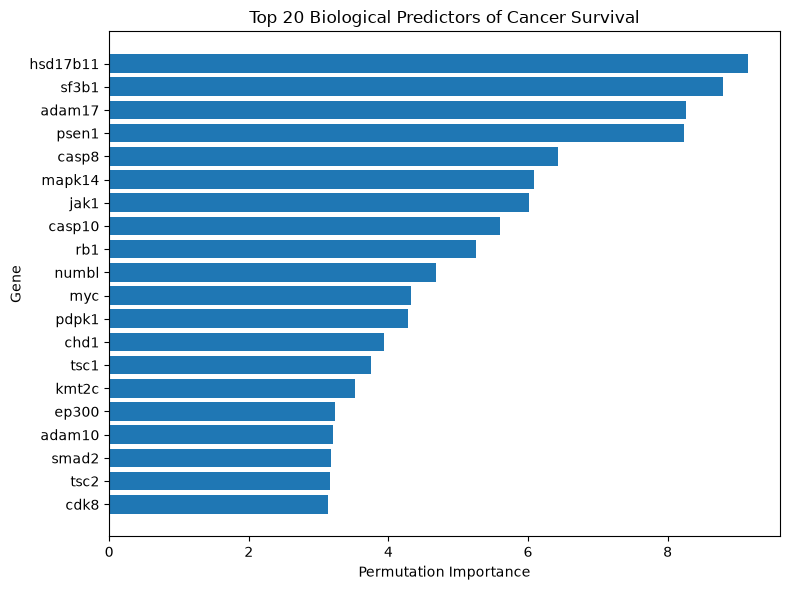

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(
    top20["Feature"][::-1],
    top20["Importance"][::-1]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Gene")
plt.title("Top 20 Biological Predictors of Cancer Survival")

plt.tight_layout()
plt.show()

In [ ]:
top20.to_csv(
    "../results/top20_survival_gene_features.csv",
    index=False
)